In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('dataset/titanic_clean.csv')
df.head()

,pclass,age,sibsp,parch,fare,survived
0,1,29,0,0,211.3375,1
1,1,0,1,2,151.5500,1
2,1,2,1,2,151.5500,0
3,1,30,1,2,151.5500,0
4,1,25,1,2,151.5500,0


In [3]:
df.shape

(1309, 6)

In [4]:
df.dtypes

pclass        int64
age           int64
sibsp         int64
parch         int64
fare        float64
survived      int64
dtype: object

In [5]:
df.isna().sum()

pclass      0
age         0
sibsp       0
parch       0
fare        0
survived    0
dtype: int64

In [6]:
features=df.iloc[:,:-1].columns
features

Index(['pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

In [7]:
target='survived'

In [8]:
len(df)

1309

In [9]:
train=df.sample(int(len(df)*.8))
print(train.shape)
train.head()


(1047, 6)


,pclass,age,sibsp,parch,fare,survived
687,3,20,0,0,7.8542,0
3,1,30,1,2,151.5500,0
319,1,31,0,0,134.5000,1
1259,3,36,0,0,7.8958,0
289,1,18,0,2,79.6500,1


In [10]:
test=df.drop(index=train.index)
print(test.shape)
test.head()

(262, 6)


,pclass,age,sibsp,parch,fare,survived
5,1,48,0,0,26.5500,1
6,1,63,1,0,77.9583,1
12,1,24,0,0,69.3000,1
13,1,26,0,0,78.8500,1
14,1,80,0,0,30.0000,1


In [11]:
from sklearn.model_selection import train_test_split
train,test=train_test_split(df,test_size=0.2, random_state=42)
print(train.shape)
print(test.shape)

(1047, 6)
(262, 6)


In [12]:
print(train.head())
test.head()

     pclass  age  sibsp  parch      fare  survived
772       3   17      0      0    7.8958         0
543       2   36      0      0   10.5000         0
289       1   18      0      2   79.6500         1
10        1   47      1      0  227.5250         0
147       1   90      0      0   42.4000         0


,pclass,age,sibsp,parch,fare,survived
1148,3,35,0,0,7.1250,0
1049,3,20,1,1,15.7417,1
982,3,90,0,0,7.8958,0
808,3,90,0,0,8.0500,0
1195,3,90,0,0,7.7500,0


In [13]:
train.survived.value_counts()

survived
0    665
1    382
Name: count, dtype: int64

In [14]:
test.survived.value_counts()

survived
0    144
1    118
Name: count, dtype: int64

In [15]:
df.survived.value_counts()

survived
0    809
1    500
Name: count, dtype: int64

In [16]:
382/500

0.764

In [17]:
665/809

0.8220024721878862

In [18]:
train_df,test_df=train_test_split(df,test_size=0.2, random_state=42,stratify=df.survived)

In [19]:
train_df.survived.value_counts()

survived
0    647
1    400
Name: count, dtype: int64

In [20]:
test_df.survived.value_counts()

survived
0    162
1    100
Name: count, dtype: int64

In [21]:
df.survived.value_counts()

survived
0    809
1    500
Name: count, dtype: int64

In [22]:
400/500

0.8

In [23]:
809*.8 #train 80%

647.2

In [24]:
809-647 #test 20%

162

In [25]:
train_df.head()

,pclass,age,sibsp,parch,fare,survived
999,3,90,0,0,7.7500,1
392,2,24,1,0,27.7208,1
628,3,11,4,2,31.2750,0
1165,3,25,0,0,7.2250,0
604,3,16,0,0,7.6500,1


# 1. 

In [26]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import cross_val_score,KFold
from sklearn.metrics import confusion_matrix, accuracy_score

In [27]:
X_train=train_df[features]
y_train=train_df[target]
X_test=test_df[features]
y_test=test_df[target]

In [28]:
X_test.head()

,pclass,age,sibsp,parch,fare
1028,3,90,1,0,24.1500
1121,3,90,1,1,22.3583
1155,3,90,0,0,7.7750
1251,3,30,0,0,8.0500
721,3,36,0,0,7.4958


In [29]:
svcmodel=SVC(kernel='linear')
CARTModel=DecisionTreeClassifier()

In [30]:
svcmodel.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [31]:
CARTModel.fit(X_train,y_train)
#after fitting train data, model is already a trained ML model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [32]:
predicted1=svcmodel.predict(X_test) #SVM
print(len(y_test))
print('Prediction:\n',predicted1)
print('Actual:\n',y_test.values)

262
Prediction:
 [0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 1 0 0 0 0 0 0 0
 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 1 1 0 0 1 0 0
 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0
 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 1 1 0 0 0 0
 0 1 0 1 0 1 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0
 0 0 0 0 1 1 1 0 1 0 1 0 0 1 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0
 1 0 1]
Actual:
 [1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0
 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0
 1 1 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0
 1 1 1 1 1 0 0 1 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0
 0 0 1 0 0 1 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 1 0

In [33]:
print('\nAlgorithm: Support Vector Machine')
res_cm = confusion_matrix(y_test, predicted1)
print('Confusion Matrix:\n',res_cm)
res_acc = accuracy_score(y_test,predicted1)
print("Accuracy:",res_acc)


Algorithm: Support Vector Machine
Confusion Matrix:
 [[132  30]
 [ 53  47]]
Accuracy: 0.683206106870229


In [34]:
(133+53)/(133+29+47+53)

0.7099236641221374

In [35]:
predicted2=CARTModel.predict(X_test)
print(len(y_test))
print('Prediction:\n',predicted2)
print('Actual:\n',y_test.values)

262
Prediction:
 [0 1 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 1 0 1 0 1 0 0 0 0
 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1
 1 1 0 0 0 0 1 1 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 1
 0 0 0 0 0 1 0 1 1 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 0
 1 0 0 0 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0 0 1 1 0
 0 1 1]
Actual:
 [1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0
 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0
 1 1 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0
 1 1 1 1 1 0 0 1 1 0 1 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0
 0 0 1 0 0 1 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 1 0

In [36]:
print('\nAlgorithm: Decision Tree Classifier')
res_cm = confusion_matrix(y_test, predicted2)
print('Confusion Matrix:\n',res_cm)
res_acc = accuracy_score(y_test,predicted2)
print("Accuracy:",res_acc)


Algorithm: Decision Tree Classifier
Confusion Matrix:
 [[116  46]
 [ 53  47]]
Accuracy: 0.6221374045801527


In [37]:
res_cm[0][0] #true negatives

np.int64(116)

In [38]:
res_cm[1][0] #false negatives

np.int64(53)

In [39]:
res_cm[1][1] #true positives

np.int64(47)

In [40]:
res_cm[0][1] #false positive

np.int64(46)

In [41]:
import pickle
pickle.dump(svcmodel,open('model_svc.pkl','wb'))
pickle.dump(CARTModel,open('model_cart.pkl','wb'))

In [42]:
model1=pickle.load(open('model_svc.pkl','rb'))

In [43]:
with open('model_svc.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

print(loaded_data)  

SVC(kernel='linear')


In [44]:
X_test.head()

,pclass,age,sibsp,parch,fare
1028,3,90,1,0,24.1500
1121,3,90,1,1,22.3583
1155,3,90,0,0,7.7750
1251,3,30,0,0,8.0500
721,3,36,0,0,7.4958


In [45]:
model1.predict([[3, 36, 0, 0, 0.698243]])

C:\Users\ALi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])

# Used Random Forest

DecisionTreeClassifier: 
 max_depth = how many question need to answer 
 leaf = datapoints 
 randomness

In [46]:
from sklearn.tree import DecisionTreeClassifier 


model2 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
model2.fit(X_train, y_train)

predicted2 = model2.predict(X_test) 

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("New Accuracy:", accuracy_score(y_test, rf_pred))

New Accuracy: 0.7061068702290076


In [49]:
from sklearn.tree import DecisionTreeClassifier 


model3 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=84)
model3.fit(X_train, y_train)

predicted3 = model3.predict(X_test)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",84
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=25, max_depth=2, random_state=21)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("New Accuracy:", accuracy_score(y_test, rf_pred))

New Accuracy: 0.7290076335877863


In [52]:
print(rf_pred)

[0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 1 0
 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0
 0 0 1]


In [53]:
df.dtypes

pclass        int64
age           int64
sibsp         int64
parch         int64
fare        float64
survived      int64
dtype: object

In [54]:
print(df.columns.tolist())

['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived']


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('dataset/titanic_clean.csv')
print('Shape:', df.shape)
df.head()

Shape: (1309, 6)


,pclass,age,sibsp,parch,fare,survived
0,1,29,0,0,211.3375,1
1,1,0,1,2,151.5500,1
2,1,2,1,2,151.5500,0
3,1,30,1,2,151.5500,0
4,1,25,1,2,151.5500,0


In [59]:
# Survival rate by passenger class
print('=== Survival Rate by Pclass ===')
print(df.groupby('pclass')['survived'].mean().round(3))

print('\n=== Survival Rate by Age Group ===')
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100],
                          labels=['child', 'teen', 'young_adult', 'adult', 'senior'])
print(df.groupby('age_group', observed=True)['survived'].mean().round(3))

df.drop(columns=['age_group'], inplace=True)  # Clean up temp column

=== Survival Rate by Pclass ===
pclass
1    0.619
2    0.430
3    0.255
Name: survived, dtype: float64

=== Survival Rate by Age Group ===
age_group
child          0.537
teen           0.402
young_adult    0.388
adult          0.410
senior         0.275
Name: survived, dtype: float64


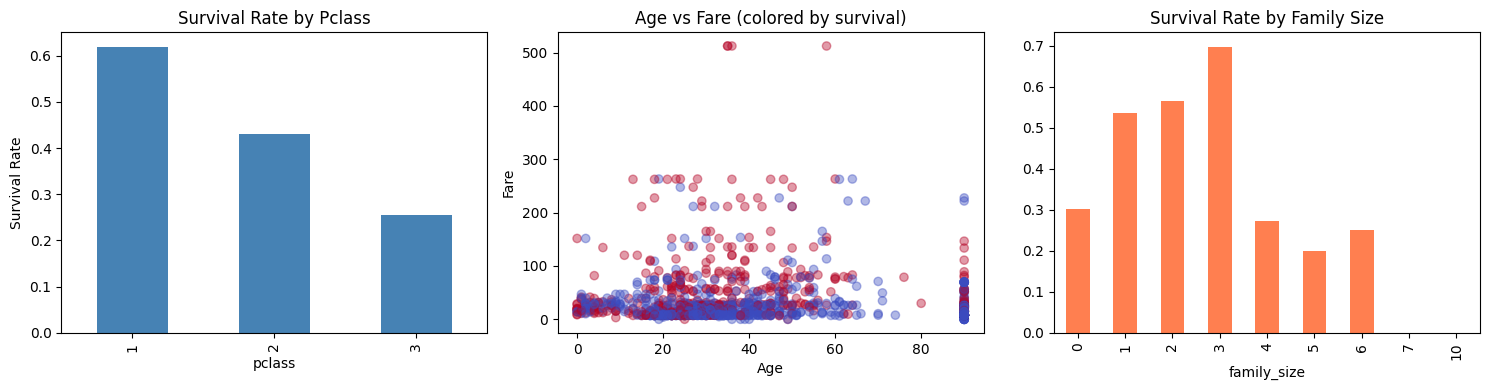

In [60]:
# Visualize correlations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Survival Rate by Pclass')
axes[0].set_ylabel('Survival Rate')

axes[1].scatter(df['age'], df['fare'], c=df['survived'], cmap='coolwarm', alpha=0.4)
axes[1].set_title('Age vs Fare (colored by survival)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Fare')

df['family_size'] = df['sibsp'] + df['parch']
df.groupby('family_size')['survived'].mean().plot(kind='bar', ax=axes[2], color='coral')
axes[2].set_title('Survival Rate by Family Size')

plt.tight_layout()
plt.show()
df.drop(columns=['family_size'], inplace=True)

In [61]:
def engineer_features(df):
    data = df.copy()

    # --- Feature 1: Family Size ---
    # Alone passengers vs small families vs large families behave differently
    data['family_size'] = data['sibsp'] + data['parch']

    # --- Feature 2: Is Alone ---
    # Solo travelers have unique survival patterns
    data['is_alone'] = (data['family_size'] == 0).astype(int)

    # --- Feature 3: Age * Pclass (interaction) ---
    # A young 1st class passenger is very different from a young 3rd class passenger
    data['age_pclass'] = data['age'] * data['pclass']

    # --- Feature 4: Fare per Person ---
    # Fare may be shared among family members; normalize it
    data['fare_per_person'] = data['fare'] / (data['family_size'] + 1)

    # --- Feature 5: Log Fare ---
    # Fare is heavily right-skewed; log transform helps models
    data['log_fare'] = np.log1p(data['fare'])

    # --- Feature 6: Is Child ---
    # Children (under 12) had higher survival priority
    data['is_child'] = (data['age'] < 12).astype(int)

    # --- Feature 7: Is Senior ---
    # Seniors (60+) had lower survival rates
    data['is_senior'] = (data['age'] >= 60).astype(int)

    # --- Feature 8: Family Size Category ---
    # Alone=0, Small(1-3)=1, Large(4+)=2
    data['family_cat'] = pd.cut(data['family_size'],
                                 bins=[-1, 0, 3, 20],
                                 labels=[0, 1, 2]).astype(int)

    return data


df_engineered = engineer_features(df)
print('Original features:', list(df.columns))
print('New features:', list(df_engineered.columns))
print('\nSample rows:')
df_engineered.head()

Original features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived']
New features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'family_size', 'is_alone', 'age_pclass', 'fare_per_person', 'log_fare', 'is_child', 'is_senior', 'family_cat']

Sample rows:


,pclass,age,sibsp,parch,fare,survived,family_size,is_alone,age_pclass,fare_per_person,log_fare,is_child,is_senior,family_cat
0,1,29,0,0,211.3375,1,0,1,29,211.3375,5.358177,0,0,0
1,1,0,1,2,151.5500,1,3,0,0,37.8875,5.027492,1,0,1
2,1,2,1,2,151.5500,0,3,0,2,37.8875,5.027492,1,0,1
3,1,30,1,2,151.5500,0,3,0,30,37.8875,5.027492,0,0,1
4,1,25,1,2,151.5500,0,3,0,25,37.8875,5.027492,0,0,1


In [62]:
# Keep original features
original_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']

# All features including engineered
engineered_features = ['pclass', 'age', 'sibsp', 'parch', 'fare',
                        'family_size', 'is_alone', 'age_pclass',
                        'fare_per_person', 'log_fare', 'is_child',
                        'is_senior', 'family_cat']

target = 'survived'

# Stratified split to preserve class balance
train_df, test_df = train_test_split(df_engineered, test_size=0.2,
                                      random_state=42, stratify=df_engineered[target])

# Original feature sets
X_train_orig = train_df[original_features]
X_test_orig  = test_df[original_features]

# Engineered feature sets
X_train = train_df[engineered_features]
X_test  = test_df[engineered_features]
y_train = train_df[target]
y_test  = test_df[target]

# Scale features (important for SVM and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Survival rate — Train: {y_train.mean():.3f}, Test: {y_test.mean():.3f}')

Train: (1047, 13), Test: (262, 13)
Survival rate — Train: 0.382, Test: 0.382


In [63]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

results = {}

# --- SVM ---
svm = SVC(kernel='linear', random_state=42)

svm.fit(X_train_orig[original_features], y_train)
results['SVM (original)'] = accuracy_score(y_test, svm.predict(X_test_orig))

svm.fit(X_train_scaled, y_train)
results['SVM (engineered+scaled)'] = accuracy_score(y_test, svm.predict(X_test_scaled))

# --- Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

dt.fit(X_train_orig, y_train)
results['DecisionTree (original)'] = accuracy_score(y_test, dt.predict(X_test_orig))

dt.fit(X_train, y_train)
results['DecisionTree (engineered)'] = accuracy_score(y_test, dt.predict(X_test))

# --- Random Forest (your best from demo5) ---
rf = RandomForestClassifier(n_estimators=25, max_depth=2, random_state=21)

rf.fit(X_train_orig, y_train)
results['RandomForest (original)'] = accuracy_score(y_test, rf.predict(X_test_orig))

rf.fit(X_train, y_train)
results['RandomForest (engineered)'] = accuracy_score(y_test, rf.predict(X_test))

print('=== Accuracy Comparison ===')
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(acc * 40)
    print(f'{name:<35} {acc:.4f}  {bar}')

=== Accuracy Comparison ===
RandomForest (original)             0.7290  █████████████████████████████
RandomForest (engineered)           0.7137  ████████████████████████████
SVM (engineered+scaled)             0.7099  ████████████████████████████
SVM (original)                      0.6832  ███████████████████████████
DecisionTree (original)             0.6679  ██████████████████████████
DecisionTree (engineered)           0.6603  ██████████████████████████


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

new_models = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                                         learning_rate=0.1, random_state=42),
    'KNN (k=5)':             KNeighborsClassifier(n_neighbors=5),
    'Random Forest (tuned)': RandomForestClassifier(n_estimators=200, max_depth=5,
                                                     min_samples_leaf=5, random_state=42),
}

print('=== New Models with Engineered Features ===')
new_results = {}
for name, model in new_models.items():
    # Use scaled features for distance-based models
    if name in ['Logistic Regression', 'KNN (k=5)']:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    new_results[name] = acc
    bar = '█' * int(acc * 40)
    print(f'{name:<30} {acc:.4f}  {bar}')

=== New Models with Engineered Features ===
Logistic Regression            0.6947  ███████████████████████████
Gradient Boosting              0.7023  ████████████████████████████
KNN (k=5)                      0.6489  █████████████████████████
Random Forest (tuned)          0.7061  ████████████████████████████


In [65]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest (tuned)': RandomForestClassifier(n_estimators=200, max_depth=5,
                                                     min_samples_leaf=5, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                                         learning_rate=0.1, random_state=42),
    'SVM (linear)':          SVC(kernel='linear', random_state=42),
}

X_all = df_engineered[engineered_features]
X_all_scaled = StandardScaler().fit_transform(X_all)
y_all = df_engineered[target]

print(f'=== 10-Fold Cross-Validation Results (n={len(df_engineered)}) ===')
print(f'{"Model":<30} {"Mean Acc":>10} {"Std Dev":>10}')
print('-' * 55)

for name, model in cv_models.items():
    if name == 'SVM (linear)':
        scores = cross_val_score(model, X_all_scaled, y_all, cv=kfold, scoring='accuracy')
    else:
        scores = cross_val_score(model, X_all, y_all, cv=kfold, scoring='accuracy')
    print(f'{name:<30} {scores.mean():.4f}     ±{scores.std():.4f}')

=== 10-Fold Cross-Validation Results (n=1309) ===
Model                            Mean Acc    Std Dev
-------------------------------------------------------


C:\Users\ALi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ALi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://sciki

Logistic Regression            0.7089     ±0.0304
Random Forest (tuned)          0.7219     ±0.0294
Gradient Boosting              0.7135     ±0.0307
SVM (linear)                   0.7112     ±0.0274


In [ ]:

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, 7, None],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print('Best parameters:', rf_grid.best_params_)
print(f'Best CV accuracy: {rf_grid.best_score_:.4f}')
print('Test accuracy:', accuracy_score(y_test, rf_grid.predict(X_test)))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV accuracy: 0.7221
Test accuracy: 0.6946564885496184


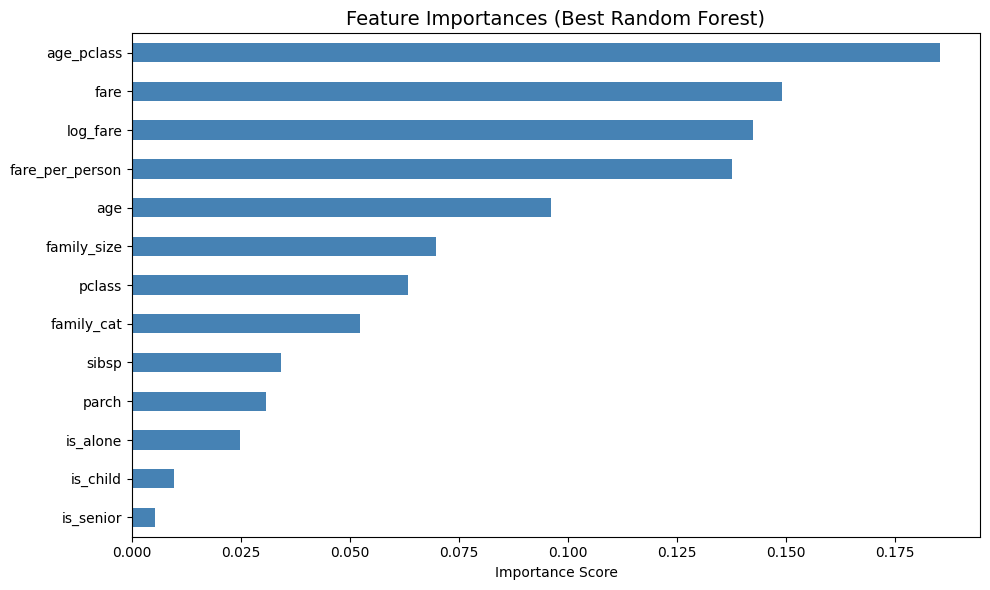


Top 5 most important features:


In [69]:
best_rf = rf_grid.best_estimator_

importances = pd.Series(best_rf.feature_importances_, index=engineered_features)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Importances (Best Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')

=== FINAL MODEL RESULTS ===
Accuracy: 0.6947

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.73      0.81      0.77       162
    Survived       0.62      0.51      0.56       100

    accuracy                           0.69       262
   macro avg       0.67      0.66      0.66       262
weighted avg       0.69      0.69      0.69       262



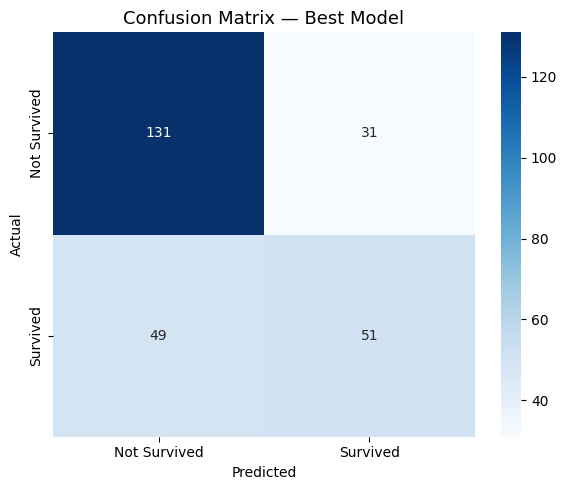

In [ ]:


final_pred = best_rf.predict(X_test)

print('=== FINAL MODEL RESULTS ===')
print(f'Accuracy: {accuracy_score(y_test, final_pred):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, final_pred, target_names=['Not Survived', 'Survived']))

cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix — Best Model', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [71]:
import pickle

# Save model and scaler together
model_bundle = {
    'model': best_rf,
    'scaler': scaler,
    'features': engineered_features
}
pickle.dump(model_bundle, open('model_best_rf.pkl', 'wb'))
print('Model saved to model_best_rf.pkl')

Model saved to model_best_rf.pkl


In [72]:
def predict_survival(pclass, age, sibsp, parch, fare, model, features):
    """Predict survival for a new passenger."""
    family_size = sibsp + parch
    data = {
        'pclass':         pclass,
        'age':            age,
        'sibsp':          sibsp,
        'parch':          parch,
        'fare':           fare,
        'family_size':    family_size,
        'is_alone':       int(family_size == 0),
        'age_pclass':     age * pclass,
        'fare_per_person': fare / (family_size + 1),
        'log_fare':       np.log1p(fare),
        'is_child':       int(age < 12),
        'is_senior':      int(age >= 60),
        'family_cat':     0 if family_size == 0 else (1 if family_size <= 3 else 2),
    }
    row = pd.DataFrame([data])[features]
    prediction = model.predict(row)[0]
    return 'SURVIVED ✅' if prediction == 1 else 'NOT SURVIVED ❌'


# --- Test examples ---
print(predict_survival(pclass=1, age=28, sibsp=0, parch=0, fare=100,
                        model=best_rf, features=engineered_features))

print(predict_survival(pclass=3, age=25, sibsp=0, parch=0, fare=7.25,
                        model=best_rf, features=engineered_features))

print(predict_survival(pclass=2, age=8, sibsp=1, parch=2, fare=30,
                        model=best_rf, features=engineered_features))

SURVIVED ✅
NOT SURVIVED ❌
SURVIVED ✅


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

def compare_results(X_test, y_actual, model, scaler, features):
    
    X_test_subset = X_test[features]
    
    
    X_test_scaled = scaler.transform(X_test_subset)
    
    predictions = model.predict(X_test_scaled)
    
    comparison_df = pd.DataFrame({
        'Actual': y_actual,
        'Predicted': predictions
    })

    comparison_df['Correct'] = comparison_df['Actual'] == comparison_df['Predicted']
    
    return comparison_df
    
results = compare_results(X_test, y_test, best_rf, scaler, engineered_features)
print(results.head(10))

      Actual  Predicted  Correct
1028       1          1     True
1121       1          1     True
1155       0          1    False
1251       0          1    False
721        0          1    False
1157       0          1    False
512        0          1    False
20         1          1     True
50         1          1     True
983        0          1    False


C:\Users\ALi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [74]:
# Print a summary report
print(classification_report(results['Actual'], results['Predicted']))

# Create a Confusion Matrix
conf_matrix = confusion_matrix(results['Actual'], results['Predicted'])
print("Confusion Matrix:")
print(conf_matrix)

              precision    recall  f1-score   support

           0       1.00      0.02      0.05       162
           1       0.39      1.00      0.56       100

    accuracy                           0.40       262
   macro avg       0.69      0.51      0.30       262
weighted avg       0.77      0.40      0.24       262

Confusion Matrix:
[[  4 158]
 [  0 100]]


Overall Accuracy: 39.69%


C:\Users\ALi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
